# Android App Market Analysis
**Level 2 - Project 4**

**Objective:** EDA on Google Play Store data to uncover market insights.



In [1]:
!pip install numpy pandas matplotlib seaborn plotly --quiet

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings; warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
print('✅ Libraries imported!')

✅ Libraries imported!


## Load Dataset

In [3]:
from google.colab import files
import io
uploaded = files.upload()
apps_file = [f for f in uploaded.keys() if 'review' not in f.lower()][0]
df = pd.read_csv(io.BytesIO(uploaded[apps_file]))
print(f'Shape: {df.shape}')
df.head()

Saving apps.csv to apps.csv
Saving user_reviews.csv to user_reviews.csv
Shape: (9659, 14)


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


## Data Exploration

In [4]:
df.info()
print(f'\nMissing values:')
print(df.isnull().sum()[df.isnull().sum()>0])
print(f'\nDuplicates: {df.duplicated().sum()}')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   object 
 2   Category        9659 non-null   object 
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   object 
 7   Type            9659 non-null   object 
 8   Price           9659 non-null   object 
 9   Content Rating  9659 non-null   object 
 10  Genres          9659 non-null   object 
 11  Last Updated    9659 non-null   object 
 12  Current Ver     9651 non-null   object 
 13  Android Ver     9657 non-null   object 
dtypes: float64(2), int64(2), object(10)
memory usage: 1.0+ MB

Missing values:
Rating         1463
Size           1227
Current Ver       8
Android Ver       2
dtype: int64


## Data Cleaning

In [5]:
df_c = df.copy()
app_col=[c for c in df_c.columns if 'app' in c.lower() or 'name' in c.lower()]
if app_col: df_c=df_c.drop_duplicates(subset=app_col[0],keep='first')

if 'Installs' in df_c.columns:
    df_c['Installs']=df_c['Installs'].astype(str).str.replace('+','',regex=False).str.replace(',','',regex=False)
    df_c['Installs']=pd.to_numeric(df_c['Installs'],errors='coerce')
if 'Price' in df_c.columns:
    df_c['Price']=df_c['Price'].astype(str).str.replace('$','',regex=False)
    df_c['Price']=pd.to_numeric(df_c['Price'],errors='coerce')
if 'Size' in df_c.columns:
    def clean_size(s):
        if isinstance(s,str):
            if 'M' in s: return float(s.replace('M',''))
            if 'k' in s: return float(s.replace('k',''))/1024
        return np.nan
    df_c['Size_MB']=df_c['Size'].apply(clean_size)
if 'Rating' in df_c.columns: df_c=df_c.dropna(subset=['Rating'])
if 'Reviews' in df_c.columns: df_c['Reviews']=pd.to_numeric(df_c['Reviews'],errors='coerce')
print(f'Cleaned: {df_c.shape}')

Cleaned: (8196, 15)


## Analysis

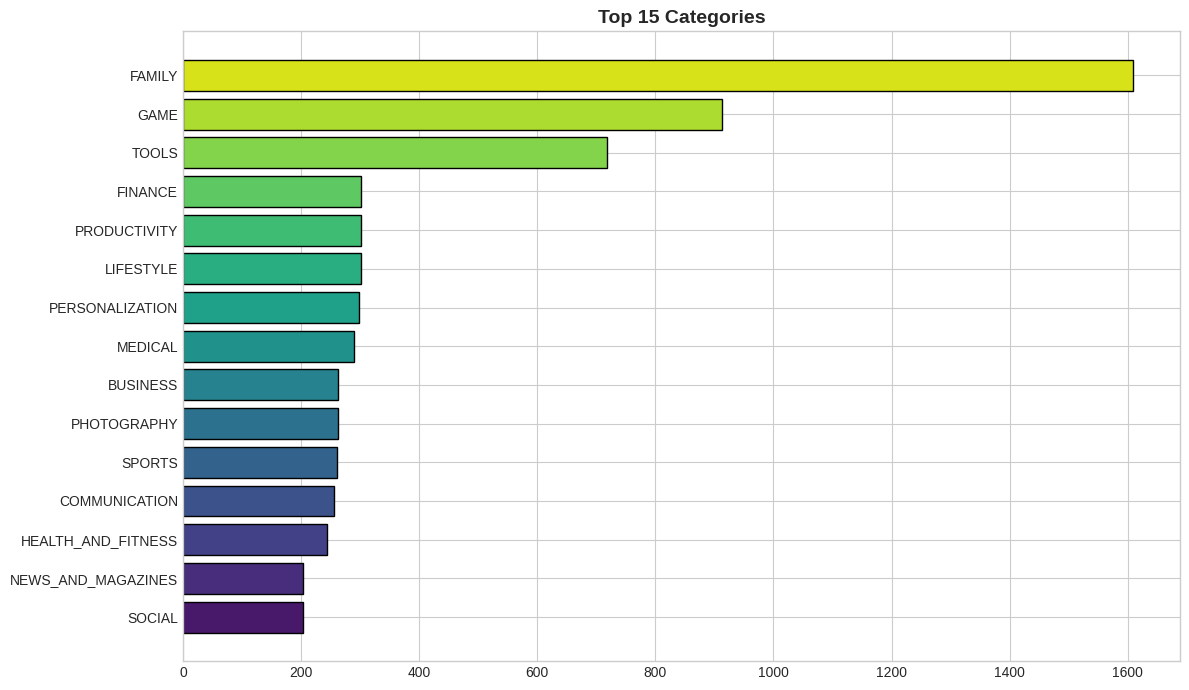

In [6]:
# Category distribution
cat_col=[c for c in df_c.columns if 'category' in c.lower() or 'genre' in c.lower()]
if cat_col:
    cat=cat_col[0]
    top=df_c[cat].value_counts().head(15)
    plt.figure(figsize=(12,7))
    plt.barh(top.index[::-1],top.values[::-1],color=sns.color_palette('viridis',15),edgecolor='black')
    plt.title('Top 15 Categories',fontsize=14,fontweight='bold')
    plt.tight_layout(); plt.show()

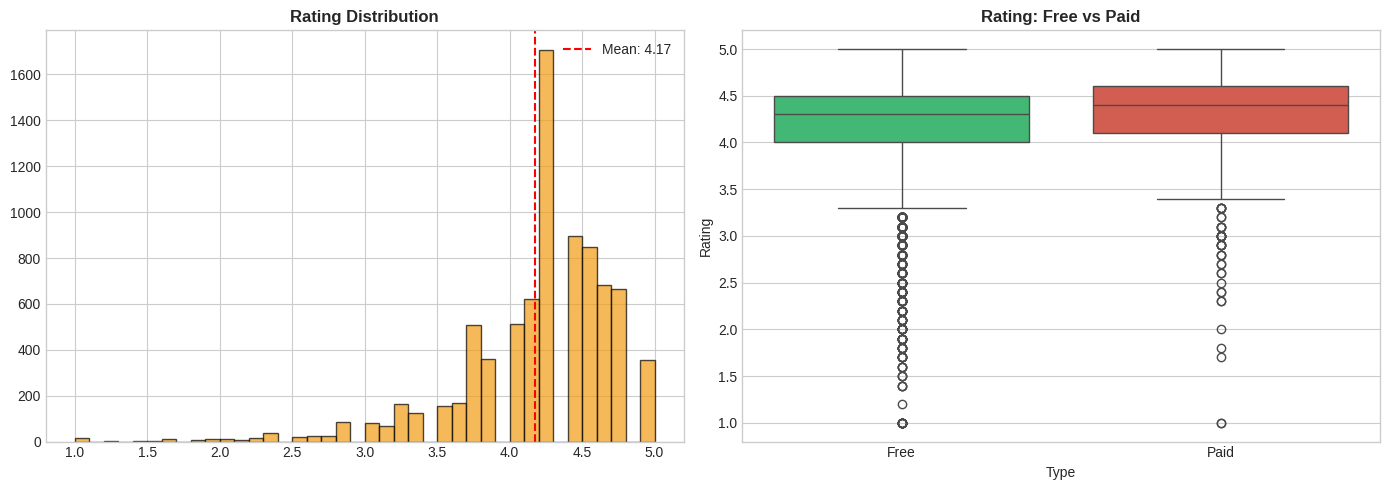

In [7]:
# Rating distribution
if 'Rating' in df_c.columns:
    fig,axes=plt.subplots(1,2,figsize=(14,5))
    axes[0].hist(df_c['Rating'],bins=40,edgecolor='black',alpha=0.7,color='#f39c12')
    axes[0].axvline(df_c['Rating'].mean(),color='red',linestyle='--',label=f'Mean: {df_c["Rating"].mean():.2f}')
    axes[0].set_title('Rating Distribution',fontweight='bold'); axes[0].legend()
    # Free vs Paid
    type_col=[c for c in df_c.columns if 'type' in c.lower()]
    if type_col:
        sns.boxplot(data=df_c,x=type_col[0],y='Rating',ax=axes[1],palette=['#2ecc71','#e74c3c'])
        axes[1].set_title('Rating: Free vs Paid',fontweight='bold')
    plt.tight_layout(); plt.show()

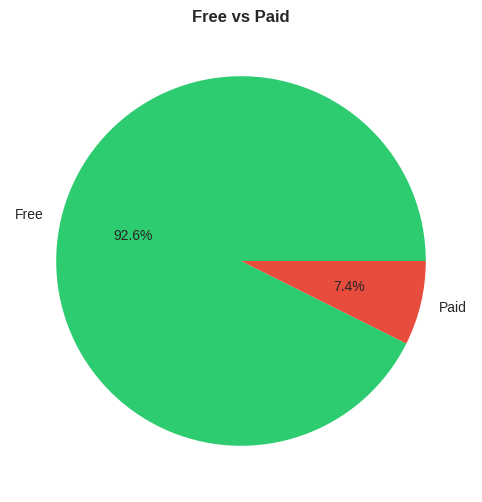

In [8]:
# Free vs Paid pie chart
type_col=[c for c in df_c.columns if 'type' in c.lower()]
if type_col:
    tc=df_c[type_col[0]].value_counts()
    plt.figure(figsize=(8,6))
    plt.pie(tc.values,labels=tc.index,autopct='%1.1f%%',colors=['#2ecc71','#e74c3c'])
    plt.title('Free vs Paid',fontweight='bold'); plt.show()

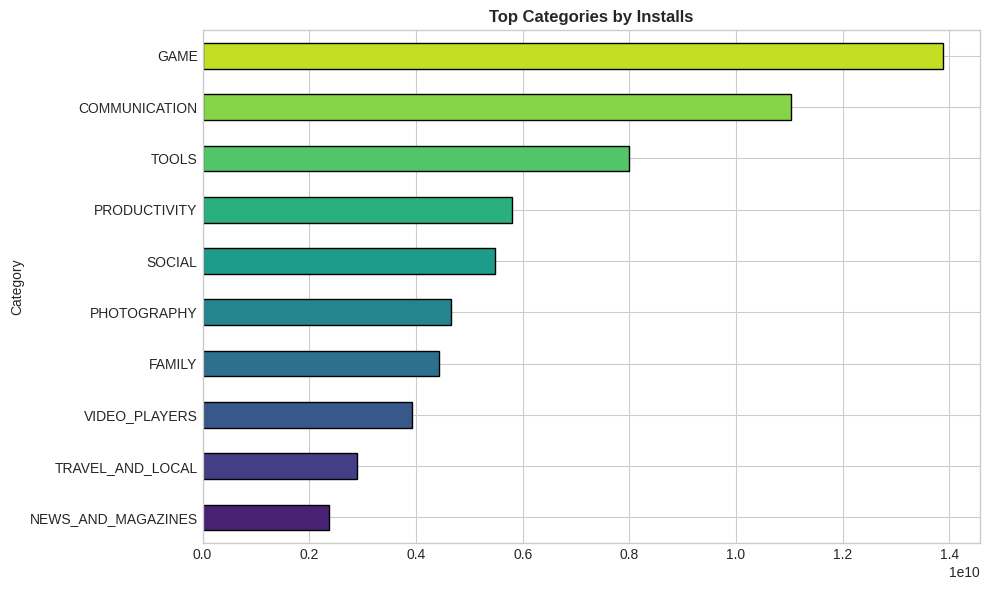

In [9]:
# Installs by category
if 'Installs' in df_c.columns and cat_col:
    top_inst=df_c.groupby(cat)['Installs'].sum().sort_values(ascending=False).head(10)
    plt.figure(figsize=(10,6))
    top_inst.sort_values().plot(kind='barh',color=sns.color_palette('viridis',10),edgecolor='black')
    plt.title('Top Categories by Installs',fontweight='bold')
    plt.tight_layout(); plt.show()

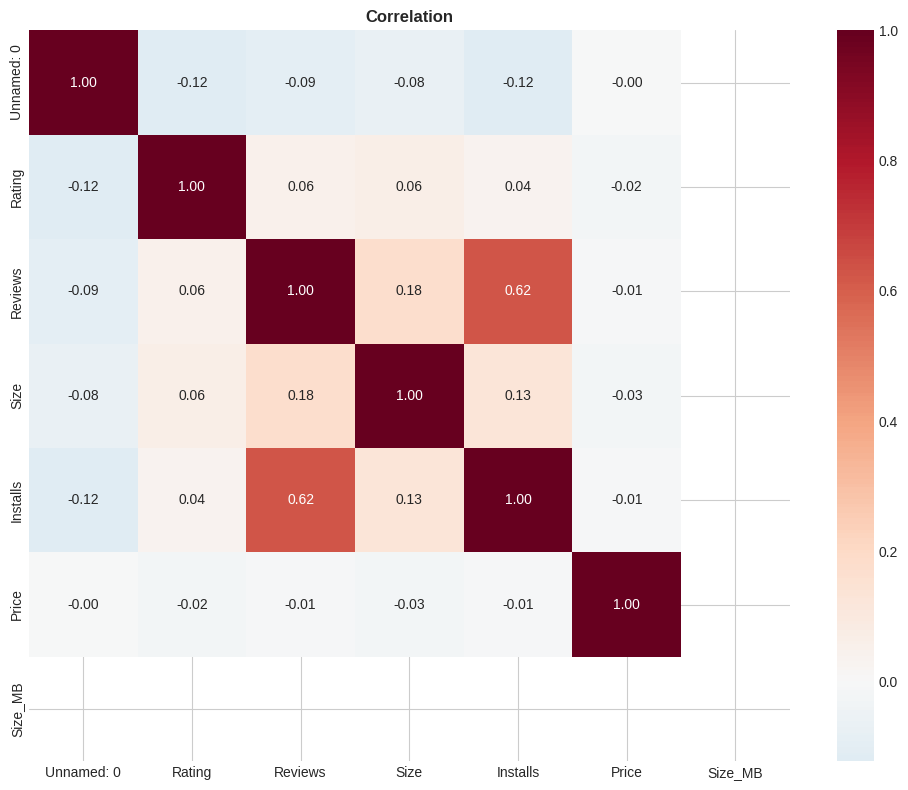

In [10]:
# Correlation
num=df_c.select_dtypes(include=[np.number]).columns
if len(num)>2:
    plt.figure(figsize=(10,8))
    sns.heatmap(df_c[num].corr(),annot=True,cmap='RdBu_r',center=0,fmt='.2f')
    plt.title('Correlation',fontweight='bold'); plt.tight_layout(); plt.show()

## Summary

In [11]:
print(f'Total apps: {len(df_c)}')
if cat_col: print(f'Categories: {df_c[cat].nunique()}')
if 'Rating' in df_c.columns: print(f'Avg Rating: {df_c["Rating"].mean():.2f}')
print('Key: Family & Games dominate. 92%+ are free. Ratings cluster around 4.0-4.5.')

Total apps: 8196
Categories: 33
Avg Rating: 4.17
Key: Family & Games dominate. 92%+ are free. Ratings cluster around 4.0-4.5.
